# Séance 3 : POO Avancée — Structures Algébriques
## Polynômes et Matrices en Python

**M1 MAFI — Université d'Antananarivo — 2026–2027**

---

### Objectifs
- Maîtriser la POO avancée : classes abstraites, héritage, surcharge d'opérateurs.
- Implémenter la classe `Polynome` (anneau $\mathbb{K}[X]$) avec Horner, dérivée, PGCD.
- Implémenter la classe `Matrice` avec élimination de Gauss–Jordan.
- Introduction légère à **Lean 4** : formalisation de propriétés élémentaires.
- Mesurer et comparer les complexités $\mathcal{O}(n)$, $\mathcal{O}(n^2)$, $\mathcal{O}(n^3)$.

---

### Ressources
- Cormen et al., *Introduction to Algorithms*, 4e éd., MIT Press, 2022 — ch. 2 (Horner), ch. 30 (FFT).
- Strang, *Computational Science and Engineering*, Wellesley-Cambridge, 2007 — ch. 1–3 (Gauss).
- Trefethen & Bau, *Numerical Linear Algebra*, SIAM, 1997 — Lecture 20.
- Avigad et al., *Mathematics in Lean*, https://leanprover-community.github.io/mathematics_in_lean/ — §8.

---
**Rappel** : l'usage des assistants IA est autorisé pour déboguer, mais vous devez comprendre et documenter chaque ligne de code.

## Partie 0 — Environnement

In [1]:
import timeit
import time
import random
import math
import copy
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

%matplotlib inline
print("Environnement prêt.")

Environnement prêt.


---
## Partie 1 — POO Avancée : Interface Algébrique

### 1.1 Classe abstraite `StructureAlgebrique`

Une **classe abstraite** (module `abc`) définit une interface que toute sous-classe doit respecter.  
Ici, on modélise un **anneau** : addition, multiplication, et élément neutre nul.

> **Référence** : Python docs, `abc` — https://docs.python.org/3/library/abc.html

In [2]:
class StructureAlgebrique(ABC):
    """Interface abstraite d'un anneau (addition + multiplication)."""

    @abstractmethod
    def __add__(self, other):
        """Addition dans la structure."""
        pass

    @abstractmethod
    def __mul__(self, other):
        """Multiplication dans la structure."""
        pass

    @property
    @abstractmethod
    def zero(self):
        """Élément neutre pour l'addition."""
        pass

    @abstractmethod
    def __eq__(self, other):
        pass

    def __ne__(self, other):
        return not self.__eq__(other)

# Test : on ne peut pas instancier une classe abstraite
try:
    s = StructureAlgebrique()
except TypeError as e:
    print(f"Erreur attendue : {e}")

Erreur attendue : Can't instantiate abstract class StructureAlgebrique without an implementation for abstract methods '__add__', '__eq__', '__mul__', 'zero'


### 1.2 Exemple : héritage et polymorphisme

**Exercice guidé** : compléter la classe `Entier` ci-dessous qui hérite de `StructureAlgebrique`.  
Elle sert d'illustration avant d'implémenter `Polynome`.

In [3]:
class Entier(StructureAlgebrique):
    """Entier comme anneau (illustration du polymorphisme)."""

    def __init__(self, valeur):
        self.val = int(valeur)

    def __add__(self, other):
        # TODO : retourner Entier(self.val + other.val)
        return Entier(self.val + other.val)
        

    def __mul__(self, other):
        # TODO : retourner Entier(self.val * other.val)
        return Entier(self.val * other.val)
      

    @property
    def zero(self):
        return Entier(0)

    def __eq__(self, other):
        if isinstance(other, Entier):
            return self.val == other.val
        return self.val == other

    def __repr__(self):
        return f"Entier({self.val})"

#Tests automatiques (décommentez après implémentation)
a, b = Entier(3), Entier(5)
assert (a + b) == Entier(8), "Addition incorrecte"
assert (a * b) == Entier(15), "Multiplication incorrecte"
print("Tests Entier OK")

Tests Entier OK


---
## Partie 2 — Classe `Polynome`

Un polynôme $P = a_0 + a_1 X + \cdots + a_n X^n \in \mathbb{K}[X]$ est représenté par la liste  
`coeffs = [a_0, a_1, ..., a_n]` (degré croissant), avec $a_n \neq 0$.

### 2.1 Initialisation et affichage

In [4]:
class Polynome(StructureAlgebrique):
    """
    Représentation d'un polynôme à coefficients réels.
    coeffs[i] est le coefficient de X^i.
    """

    def __init__(self, coeffs):
        """coeffs : liste/tuple de coefficients (degré croissant)."""
        self.coeffs = list(coeffs)
        self._normaliser()

    def _normaliser(self):
        """Supprime les zéros dominants."""
        while len(self.coeffs) > 1 and self.coeffs[-1] == 0:
            self.coeffs.pop()

    @property
    def degre(self):
        """Degré du polynôme (-1 pour le polynôme nul)."""
        if self.coeffs == [0]:
            return -1
        return len(self.coeffs) - 1

    @property
    def zero(self):
        return Polynome([0])

    def __getitem__(self, i):
        """Coefficient de X^i."""
        return self.coeffs[i] if 0 <= i < len(self.coeffs) else 0

    def __eq__(self, other):
        if isinstance(other, (int, float)):
            return self.coeffs == [other]
        if isinstance(other, Polynome):
            return self.coeffs == other.coeffs
        return NotImplemented

    def __repr__(self):
        return f"Polynome({self.coeffs})"

    def __str__(self):
        if self.degre == -1:
            return "0"
        termes = []
        for i, c in enumerate(self.coeffs):
            if c == 0:
                continue
            if i == 0:
                termes.append(str(c))
            elif i == 1:
                termes.append(f"({c})*X" if c != 1 else "X")
            else:
                termes.append(f"({c})*X^{i}" if c != 1 else f"X^{i}")
        return " + ".join(reversed(termes)) if termes else "0"

    def __call__(self, x):
        """Permet d'écrire P(x) directement."""
        return self.evaluer(x)

    def __add__(self, other):
        max_len = max(len(self.coeffs), len(other.coeffs))
        new_coeffs = []
        for i in range(max_len):
            c1 = self.coeffs[i] if i < len(self.coeffs) else 0
            c2 = other.coeffs[i] if i < len(other.coeffs) else 0
            new_coeffs.append(c1 + c2)
        return Polynome(new_coeffs)

    def __mul__(self, other):
        """Multiplication par Karatsuba (à implémenter)."""
    # Soient P et Q deux polynomes
    # Si degré(P) = n alors il y a taille = n+1 coefficients
    # Si degré(Q) = m alors taille = m+1 
    # Donc, degré(P*Q)= n+m alors taille= (n+1)+(m+1)-1= n+m+1
        taille = len(self.coeffs) + len(other.coeffs) - 1
    #Listes remplie de zéro
        new_coeffs = [0] * taille
    #Multiplucation des coefficients       
        for i in range (len(self.coeffs)):
            for j in range (len(other.coeffs)):
                # Ajout du produit à la bonne position
                new_coeffs[i + j] += (self.coeffs[i] * other.coeffs[j])
        # Retour du polynome resultat
        return Polynome(new_coeffs)

# Test rapide
P = Polynome([1, -2, 0, 3])   # 1 - 2X + 3X^3
print(f"P = {P}")
print(f"deg(P) = {P.degre}")
print(f"P[0] = {P[0]}, P[3] = {P[3]}")

P = (3)*X^3 + (-2)*X + 1
deg(P) = 3
P[0] = 1, P[3] = 3


### 2.2 Opérations arithmétiques (à compléter)

**Rappel mathématique** :
$$P + Q = \sum_{k=0}^{\max(m,n)} (a_k + b_k) X^k \qquad P \cdot Q = \sum_{k=0}^{m+n}\left(\sum_{i+j=k} a_i b_j\right) X^k$$

In [5]:
def polynome_add(self, other):
    """
    Addition de deux polynômes.
    Complexité : O(max(deg P, deg Q)).
    """
    # TODO : calculer n = max longueur des deux listes de coefficients
    # Indice : utiliser self[i] + other[i] pour i in range(n)

    # Calcul de la longueur maximale entre les deux listes de coefficients
    n = max(len(self.coeffs), len(other.coeffs))
    
    resultat = [self[i] + other[i] for i in range(n)]
    return Polynome (resultat)

def polynome_neg(self):
    """Opposé d'un polynôme."""
    return Polynome([-c for c in self.coeffs])

def polynome_sub(self, other):
    """Soustraction : P - Q = P + (-Q)."""
    return self.__add__(other.__neg__())

def polynome_mul(self, other):
    """
    Multiplication naïve de deux polynômes.
    Complexité : O(deg(P) * deg(Q)).
    """
    if isinstance(other, (int, float)):
        return Polynome([c * other for c in self.coeffs])
    # TODO : initialiser un tableau resultat de taille deg(P)+deg(Q)+1
    # puis accumuler les produits a_i * b_j dans resultat[i+j]
    m, n = self.degre, other.degre
    if m == -1 or n == -1:
        return Polynome([0])
    # Le degré du produit est égal à deg(P) + deg(Q) = m + n
    # taille = nombre de coefficients
    # taille de P = degre(P) + 1 et taille de Q = degre(Q) + 1
    # taille de (P*Q) = m + n + 1
    taille = m + n + 1
    resultat = [0] * taille
    
    # Double boucle pour accumuler les produits des coefficients
    for i in range(len(self.coeffs)):
        for j in range(len(other.coeffs)):
            resultat[i + j] += self.coeffs[i] * other.coeffs[j]
            
    return Polynome(resultat)


def polynome_rmul(self, scalaire):
    return self.__mul__(scalaire)

def polynome_pow(self, n):
    """
    Exponentiation rapide (squaring).
    Complexité : O(deg(P)^2 * log n).
    """
    if n == 0:
        return Polynome([1])
    # TODO : implémenter l'exponentiation rapide (diviser par 2)
    # Si n est pair : P^n = (P^(n/2))^2
    if n % 2 == 0:
        moitie = self.__pow__(n // 2)
        return moitie * moitie
    # Si n est impair : P^n = P * P^(n-1)
    else:
        return self * self.__pow__(n - 1)

# Injection des méthodes dans la classe
Polynome.__add__  = polynome_add
Polynome.__neg__  = polynome_neg
Polynome.__sub__  = polynome_sub
Polynome.__mul__  = polynome_mul
Polynome.__rmul__ = polynome_rmul
Polynome.__pow__  = polynome_pow

#Tests automatiques (décommentez après implémentation)
P = Polynome([1, 2, 1])  # (X+1)^2
Q = Polynome([1, 1])     # X+1
assert P + Q == Polynome([2, 3, 1]), f"Addition : {P + Q}"
assert P * Q == Polynome([1, 3, 3, 1]), f"Multiplication : {P * Q}"
assert Q ** 2 == P, f"Puissance : {Q**2}"
print(f"P = {P}")
print(f"Q = {Q}")
print(f"P + Q = {P+Q}")
print(f"P * Q = {P*Q}")
print(f"Q^2 = {Q**2}")
print("Tests opérations OK")
    

P = X^2 + (2)*X + 1
Q = X + 1
P + Q = X^2 + (3)*X + 2
P * Q = X^3 + (3)*X^2 + (3)*X + 1
Q^2 = X^2 + (2)*X + 1
Tests opérations OK


### 2.3 Évaluation : méthode de Horner (à compléter)

**Algorithme de Horner (1819)** — évaluation en $\mathcal{O}(n)$ :
$$P(x) = a_0 + x\bigl(a_1 + x(a_2 + \cdots + x(a_{n-1} + x \cdot a_n)\cdots)\bigr)$$

> Référence : Knuth, *TAOCP* vol. 2, §4.6.4.

In [6]:
def polynome_evaluer(self, x):
    """
    Évalue P(x) par la méthode de Horner.
    Complexité : O(n) où n = deg(P).

    Algorithme :
        resultat = 0
        Parcourir les coefficients de a_n à a_0 :
            resultat = resultat * x + coeff
        Retourner resultat
    """
    # TODO
    resultat = 0
    # reversed() permet de commencer par le coefficient du plus haut degré (a_n)
    for coeff in reversed(self.coeffs):
        resultat = resultat * x + coeff
        
    return resultat

def polynome_evaluer_naif(self, x):
    """
    Évalue P(x) terme à terme (méthode naïve).
    Complexité : O(n^2) — calcule x^i pour chaque i.
    """
    return sum(self.coeffs[i] * (x ** i) for i in range(len(self.coeffs)))

Polynome.evaluer       = polynome_evaluer
Polynome.evaluer_naif  = polynome_evaluer_naif

#Tests
P = Polynome([-5, 1, -2, 3])  # 3X^3 - 2X^2 + X - 5
assert P.evaluer(2) == 13, f"Horner : {P.evaluer(2)}"
assert P.evaluer_naif(2) == 13, f"Naïf : {P.evaluer_naif(2)}"
print(f"P(x) = {P}")
print(f"P(2) = {P.evaluer(2)}  (attendu : 13)")

P(x) = (3)*X^3 + (-2)*X^2 + X + -5
P(2) = 13  (attendu : 13)


### 2.4 Dérivée formelle (à compléter)

Si $P = \sum_{i=0}^{n} a_i X^i$, alors $P' = \sum_{i=1}^{n} i \cdot a_i X^{i-1}$.

In [7]:
def polynome_derivee(self):
    """
    Dérivée formelle de P.
    Complexité : O(n).
    """
    if self.degre <= 0:
        return Polynome([0])
    # TODO : retourner Polynome([i * self.coeffs[i] for i in range(1, len(...))])
    # return Polynome([i * self.coeffs[i] for i in range(1, len(self.coeffs))]
    # La dérivée fait disparaître a_0, et chaque terme a_i * X^i devient (i * a_i) * X^(i-1)
    return Polynome([i * self.coeffs[i] for i in range(1, len(self.coeffs))])
    

def polynome_integrer(self, constante=0):
    """
    Primitive de P avec constante d'intégration.
    Si P = sum a_i X^i, alors intégrale = constante + sum (a_i/(i+1)) X^{i+1}.
    Complexité : O(n).
    """
    # TODO
    # La constante d'intégration devient le coefficient de degré 0
    # On ajoute ensuite chaque coefficient divisé par son nouvel exposant (i + 1)
    coeffs_integration = [constante] + [c / (i + 1) for i, c in enumerate(self.coeffs)]
    
    return Polynome(coeffs_integration)

Polynome.derivee  = polynome_derivee
Polynome.integrer = polynome_integrer

#Tests
P = Polynome([0, 0, 1])   # X^2
assert P.derivee() == Polynome([0, 2]), f"Dérivée : {P.derivee()}"  # 2X
assert P.integrer() == Polynome([0, 0, 0, 1/3]), f"Intégrale : {P.integrer()}"
print("Tests dérivée/intégrale OK")

Tests dérivée/intégrale OK


### 2.5 Division euclidienne et PGCD (à compléter)

**Théorème** : pour tout $A, B \in \mathbb{K}[X]$ avec $B \neq 0$, il existe $(Q, R)$ unique tel que  
$A = BQ + R$ et $\deg(R) < \deg(B)$.

L'**algorithme d'Euclide** pour les polynômes est identique à celui des entiers.

In [8]:
def polynome_division(self, diviseur):
    """
    Division euclidienne : retourne (Q, R) tels que self = diviseur*Q + R.
    Algorithme : division longue, similaire à la division de grands entiers.
    Complexité : O(deg(self) * deg(diviseur)).
    """
    if diviseur == Polynome([0]):
        raise ZeroDivisionError("Division par le polynôme nul")
    dividende = Polynome(self.coeffs[:])
    quotient  = Polynome([0])
    while dividende.degre >= diviseur.degre:
        deg_diff = dividende.degre - diviseur.degre
        coeff    = dividende.coeffs[-1] / diviseur.coeffs[-1]
        monome   = Polynome([0] * deg_diff + [coeff])
        quotient  = quotient + monome
        dividende = dividende - (monome * diviseur)
    return quotient, dividende


def polynome_pgcd(A, B):
    """
    PGCD de A et B par l'algorithme d'Euclide.
    Retourne un représentant normalisé (coefficient dominant = 1).
    Complexité : O(n^2) où n = max(deg A, deg B).

    Terminaison : le degré du reste décroît strictement à chaque étape.
    """
    # TODO : implémenter la boucle while B != Polynome([0])
    # puis normaliser le résultat (diviser par le coefficient dominant)

    # Boucle de l'algorithme d'Euclide
    while B != Polynome([0]):
        _, reste = A.division_euclidienne(B)
        A = B
        B = reste
    
    # Normalisation : on rend le polynôme "unitaire" en divisant par son coefficient dominant
    if A != Polynome([0]):
        coeff_dominant = A.coeffs[-1]
        A = A * (1 / coeff_dominant)
        
    return A
    

Polynome.division_euclidienne = polynome_division
Polynome.pgcd = staticmethod(polynome_pgcd)

# Tests
A = Polynome([-1, 0, 0, 1])   # X^3 - 1
B = Polynome([-1, 0, 1])       # X^2 - 1
G = Polynome.pgcd(A, B)
print(f"pgcd(X^3-1, X^2-1) = {G}")  # attendu : X - 1
Q, R = A.division_euclidienne(B)
print(f"Vérification : B*Q + R = {B*Q + R}")  # doit égaler A

pgcd(X^3-1, X^2-1) = X + -1.0
Vérification : B*Q + R = X^3 + -1


---
## Partie 3 — Classe `Matrice`

> Référence principale : Strang, *CSE*, ch. 1–3 ; Trefethen & Bau, Lectures 20–23.

### 3.1 Initialisation et affichage

In [9]:
class Matrice:
    """
    Matrice m×n de réels, stockée en liste de listes (lignes).
    """

    def __init__(self, lignes):
        self.data = [list(lig) for lig in lignes]
        self.m = len(self.data)
        self.n = len(self.data[0]) if self.data else 0

    @classmethod
    def nulle(cls, m, n):
        """Matrice nulle m×n."""
        return cls([[0.0] * n for _ in range(m)])

    @classmethod
    def identite(cls, n):
        """Matrice identité n×n."""
        M = cls.nulle(n, n)
        for i in range(n):
            M.data[i][i] = 1.0
        return M

    @classmethod
    def aleatoire(cls, m, n, entiers=False, borne=10):
        """Matrice aléatoire m×n."""
        if entiers:
            return cls([[random.randint(-borne, borne) for _ in range(n)]
                        for _ in range(m)])
        return cls([[random.uniform(-borne, borne) for _ in range(n)]
                    for _ in range(m)])

    def __getitem__(self, idx):
        i, j = idx
        return self.data[i][j]

    def __setitem__(self, idx, val):
        i, j = idx
        self.data[i][j] = val

    def __repr__(self):
        return f"Matrice({self.data})"

    def __str__(self):
        larg = max(len(f"{self.data[i][j]:.3g}")
                   for i in range(self.m) for j in range(self.n))
        rows = ["  ".join(f"{x:{larg}.3g}" for x in ligne)
                for ligne in self.data]
        return "\n".join(f"| {r} |" for r in rows)

# Exemple
A = Matrice([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(A)
print(f"\nDimensions : {A.m} x {A.n}")

| 1  2  3 |
| 4  5  6 |
| 7  8  9 |

Dimensions : 3 x 3


### 3.2 Opérations arithmétiques (à compléter)

| Opération | Complexité |
|-----------|------------|
| Addition $A + B$ | $\mathcal{O}(mn)$ |
| Transposée $A^T$ | $\mathcal{O}(mn)$ |
| Multiplication $A \cdot B$ | $\mathcal{O}(mnp)$ — naïf |

In [10]:
def matrice_add(self, other):
    """
    Addition terme à terme. Complexité : O(m*n).
    Précondition : self et other ont les mêmes dimensions.
    """
    assert self.m == other.m and self.n == other.n, "Dimensions incompatibles"
    # TODO
    # On additionne les éléments ayant les mêmes indices (i, j)
    # A = (a[i][j]) et B = (b[i][j]) alors A+B = (a[i][j] + b[i][j])
    nouvelle_data = [[self.data[i][j] + other.data[i][j] for j in range(self.n)]for i in range(self.m)]
    return Matrice(nouvelle_data)
  

def matrice_neg(self):
    return Matrice([[-x for x in lig] for lig in self.data])

def matrice_sub(self, other):
    return self.__add__(other.__neg__())

def matrice_mul(self, other):
    """
    Multiplication matricielle naïve. Complexité : O(m * n * p).
    Précondition : self est m×n, other est n×p.

    C[i][j] = sum_{k=0}^{n-1} A[i][k] * B[k][j]
    """
    if isinstance(other, (int, float)):
        return Matrice([[other * x for x in lig] for lig in self.data])
    assert self.n == other.m, f"Dimensions : ({self.m},{self.n}) x ({other.m},{other.n})"
    # TODO : construire la matrice résultat case par case

    # Dimensions de la matrice résultante : m (lignes de A) x p (colonnes de B)
    m = self.m
    n = self.n
    p = other.n
    
    # Initialisation de la matrice résultat avec des zéros
    resultat = [[0] * p for _ in range(m)]
    
    # Calcul de chaque coefficient de la matrice produit
    for i in range(m):
        for j in range(p):
            resultat[i][j] = sum(self.data[i][k] * other.data[k][j] for k in range(n))
            
    return Matrice(resultat)
    

def matrice_transposee(self):
    """
    Transposée : (A^T)[i][j] = A[j][i]. Complexité : O(m*n).
    """
    # TODO
    # Les lignes deviennent les colonnes et les colonnes deviennent les lignes.
    # La nouvelle matrice aura 'self.n' lignes et 'self.m' colonnes.
    data_transp = [[self.data[j][i] for j in range(self.m)]for i in range(self.n)]
    return Matrice(data_transp)


def matrice_trace(self):
    """Trace (matrice carrée). Complexité : O(n)."""
    assert self.m == self.n, "La trace nécessite une matrice carrée"
    return sum(self.data[i][i] for i in range(self.n))

def matrice_eq(self, other):
    if not isinstance(other, Matrice):
        return NotImplemented
    return self.data == other.data

Matrice.__add__       = matrice_add
Matrice.__neg__       = matrice_neg
Matrice.__sub__       = matrice_sub
Matrice.__mul__       = matrice_mul
Matrice.transposee    = matrice_transposee
Matrice.trace         = matrice_trace
Matrice.__eq__        = matrice_eq

# Tests
A = Matrice([[1, 2], [3, 4]])
B = Matrice([[5, 6], [7, 8]])
print("A + B ="); print(A + B)
print("A * B ="); print(A * B)   # [[19,22],[43,50]]
print("A^T  ="); print(A.transposee())
print(f"tr(A) = {A.trace()}")    # 5

A + B =
|  6   8 |
| 10  12 |
A * B =
| 19  22 |
| 43  50 |
A^T  =
| 1  3 |
| 2  4 |
tr(A) = 5


### 3.3 Élimination de Gauss–Jordan avec pivot partiel (à compléter)

**Algorithme** (Strang, CSE, ch. 1) :
1. Pour chaque colonne pivot : choisir la ligne avec le plus grand $|a_{ij}|$ (*pivot partiel*).
2. Normaliser la ligne pivot (diviser par le pivot).
3. Éliminer dans **toutes** les autres lignes (forme réduite RREF).

**Complexité** : $\mathcal{O}(n^3)$.

In [11]:
def matrice_gauss_jordan(self, b=None):
    """
    Élimination de Gauss–Jordan avec pivot partiel.

    - Si b est fourni (liste de n réels) : résout Ax = b et retourne x.
    - Sinon : retourne la forme échelonnée réduite (RREF) de A.

    Complexité : O(n^3).
    Référence : Trefethen & Bau, Numerical Linear Algebra, Lecture 20.
    """
    n = self.m
    # Construction de la matrice augmentée [A | b] ou copie de A
    if b is not None:
        M = [self.data[i][:] + [float(b[i])] for i in range(n)]
        ncols = n + 1
    else:
        M = [lig[:] for lig in self.data]
        ncols = self.n

    pivot_col = 0
    for pivot_row in range(n):
        if pivot_col >= ncols:
            break
        # Pivot partiel
        max_row = max(range(pivot_row, n), key=lambda r: abs(M[r][pivot_col]))
        if abs(M[max_row][pivot_col]) < 1e-12:
            pivot_col += 1
            continue
        M[pivot_row], M[max_row] = M[max_row], M[pivot_row]
        # TODO :
        # 1. Normaliser la ligne pivot_row (diviser par M[pivot_row][pivot_col])
        # 2. Pour chaque ligne i != pivot_row, éliminer la colonne pivot_col
        #    M[i] = M[i] - M[i][pivot_col] * M[pivot_row]
        
        # 1. Normaliser la ligne pivot_row (diviser par M[pivot_row][pivot_col])
        pivot_val = M[pivot_row][pivot_col]
        for j in range(pivot_col, ncols):
            M[pivot_row][j] /= pivot_val
            
        for i in range(n):
            if i != pivot_row:
                factor = M[i][pivot_col]
                for j in range(pivot_col, ncols):
                    M[i][j] -= factor * M[pivot_row][j]
        pivot_col += 1

    if b is not None:
        return [M[i][-1] for i in range(n)]
    return Matrice([lig[:self.n] for lig in M])

Matrice.gauss_jordan = matrice_gauss_jordan

# Tests (décommentez après implémentation)
A = Matrice([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]])
b = [8, -11, -3]
x = A.gauss_jordan(b)
print(f"Solution : {[round(xi, 6) for xi in x]}")  # [2.0, 3.0, -1.0]
# Vérification : Ax doit donner b
Ax = [sum(A[i,j]*x[j] for j in range(3)) for i in range(3)]
print(f"Vérification Ax = {[round(v,6) for v in Ax]}")  # [8, -11, -3]

Solution : [2.0, 3.0, -1.0]
Vérification Ax = [8.0, -11.0, -3.0]


### 3.4 Déterminant (à compléter)

Le déterminant se calcule en $\mathcal{O}(n^3)$ par l'élimination de Gauss :  
$\det(A) = \prod_i u_{ii}$ (produit des pivots), avec signe $-1$ par échange de lignes.

In [12]:
def matrice_determinant(self):
    """
    Déterminant par élimination de Gauss avec pivot partiel.
    Complexité : O(n^3).

    Principe : det(A) = (+/-1) * produit des pivots,
    avec signe -1 pour chaque échange de lignes.
    """
    assert self.m == self.n, "Le déterminant est défini pour les matrices carrées"
    n = self.m
    M   = [lig[:] for lig in self.data]
    det = 1.0
    for col in range(n):
        # TODO :
        # 1. Trouver la ligne avec le plus grand |M[r][col]| pour r >= col
        max_row = max(range(col, n), key=lambda r: abs(M[r][col]))
        # 2. Si ce maximum est < 1e-12 : retourner 0.0 (matrice singulière)
        if abs(M[max_row][col]) < 1e-12:
            return 0.0
        # 3. Échanger les lignes si nécessaire et multiplier det par -1
        if max_row != col:
            M[col], M[max_row] = M[max_row], M[col]
            det *= -1.0  # L'échange de lignes inverse le signe du déterminant
        # 4. Mettre à jour det *= M[col][col]
        pivot = M[col][col]
        det *= pivot
        # 5. Éliminer en dessous
        # On ne traite que les lignes situées sous le pivot (col + 1 jusqu'à n)
        for i in range(col + 1, n):
            factor = M[i][col] / pivot
            # On soustrait la ligne du pivot multipliée par le facteur
            # Pas besoin de traiter les colonnes avant 'col' car elles sont déjà à 0
            for j in range(col, n):
                M[i][j] -= factor * M[col][j]
    return det

Matrice.determinant = matrice_determinant

# Tests
print(Matrice([[1,2],[3,4]]).determinant())         # -2
print(Matrice([[2,1,-1],[-3,-1,2],[-2,1,2]]).determinant())  # -1
print(Matrice.identite(4).determinant())             # 1

-2.0
-0.9999999999999993
1.0


---
## Partie 4 — Introduction à Lean 4

> **Référence** : Avigad et al., *Mathematics in Lean*, §8 — Polynomials and Power Series.  
> Installer Lean 4 + Mathlib : https://leanprover-community.github.io/get_started.html

Cette partie est à réaliser **dans VS Code avec l'extension Lean 4**, pas dans Jupyter.  
Copiez le code ci-dessous dans un fichier `seance3.lean` et observez les résultats dans l'InfoView.

### Concepts clés de Lean 4 pour les polynômes

Dans **Mathlib**, les polynômes à coefficients dans un anneau `R` sont le type `Polynomial R`.  
L'évaluation en `x : R` est `Polynomial.eval x P`.

```lean
-- Fichier : seance3.lean
-- Importer Mathlib (après avoir configuré votre projet Lean)
import Mathlib.RingTheory.Polynomial.Basic
import Mathlib.Data.Polynomial.Degree.Definitions
import Mathlib.Data.Polynomial.Eval

open Polynomial

-- ───────────────────────────────────────────────────────────────
-- Lemme 1 : L'évaluation est un homomorphisme d'anneaux
-- (P + Q)(x) = P(x) + Q(x)
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) (x : ℝ) :
    (P + Q).eval x = P.eval x + Q.eval x := by
  simp [eval_add]

-- ───────────────────────────────────────────────────────────────
-- Lemme 2 : Commutativité de l'addition dans ℝ[X]
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) : P + Q = Q + P := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Lemme 3 : deg(P + Q) ≤ max(deg P, deg Q)
-- (Ce résultat est natDegree_add_le dans Mathlib)
-- ───────────────────────────────────────────────────────────────
example (P Q : Polynomial ℝ) :
    (P + Q).natDegree ≤ max P.natDegree Q.natDegree :=
  natDegree_add_le P Q

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.1 : Montrer que (X + 1)² = X² + 2X + 1
-- ───────────────────────────────────────────────────────────────
example : (X + 1 : Polynomial ℤ) ^ 2 = X ^ 2 + 2 * X + 1 := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.2 : X³ - 1 = (X - 1)(X² + X + 1)
-- ───────────────────────────────────────────────────────────────
example : (X ^ 3 - 1 : Polynomial ℤ) =
          (X - 1) * (X ^ 2 + X + 1) := by
  ring

-- ───────────────────────────────────────────────────────────────
-- Exercice Lean 4.3 (ouvert) : Montrer que si P(a) = 0,
-- alors (X - a) divise P dans ℝ[X].
-- Chercher : Polynomial.dvd_iff_isRoot dans Mathlib
-- ───────────────────────────────────────────────────────────────
#check Polynomial.dvd_iff_isRoot
```

---
## Partie 5 — Analyse de Complexité Empirique

### 5.1 Horner vs évaluation naïve

deg= 100 | Horner: 14.26 µs | Naïf: 65.56 µs
deg= 300 | Horner: 38.56 µs | Naïf: 142.16 µs
deg= 600 | Horner: 72.00 µs | Naïf: 293.20 µs
deg=1000 | Horner: 92.24 µs | Naïf: 315.06 µs
deg=2000 | Horner: 284.00 µs | Naïf: 1775.66 µs


deg=3000 | Horner: 597.34 µs | Naïf: 1758.92 µs


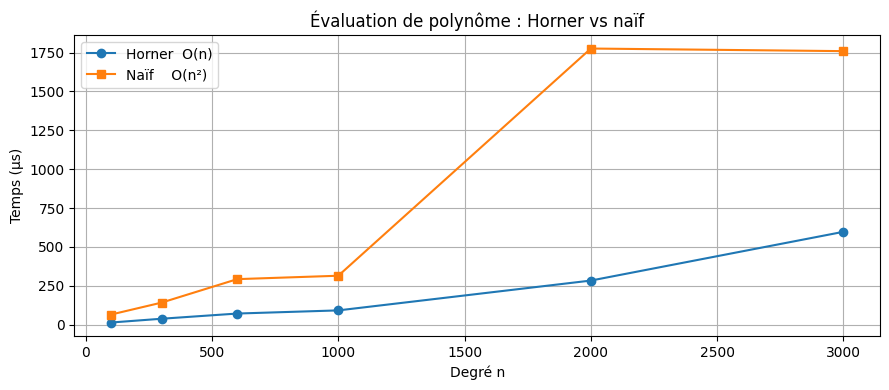

In [13]:
# NOTE : cette cellule nécessite que polynome_evaluer et polynome_evaluer_naif
# soient correctement implémentées (Partie 2.3)

def mesurer(f, *args, rep=5):
    t = timeit.Timer(lambda: f(*args))
    return t.timeit(number=rep) / rep

degres = [100, 300, 600, 1000, 2000, 3000]
temps_horner = []
temps_naif   = []

for d in degres:
    coeffs = [random.uniform(-1, 1) for _ in range(d + 1)]
    P = Polynome(coeffs)
    x = 0.5
    th = mesurer(P.evaluer, x)
    tn = mesurer(P.evaluer_naif, x)
    temps_horner.append(th)
    temps_naif.append(tn)
    print(f"deg={d:4d} | Horner: {th*1e6:.2f} µs | Naïf: {tn*1e6:.2f} µs")

plt.figure(figsize=(9, 4))
plt.plot(degres, [t*1e6 for t in temps_horner], 'o-', label='Horner  O(n)')
plt.plot(degres, [t*1e6 for t in temps_naif],   's-', label='Naïf    O(n²)')
plt.xlabel('Degré n')
plt.ylabel('Temps (µs)')
plt.title('Évaluation de polynôme : Horner vs naïf')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Question** : La courbe « naïf » ressemble-t-elle à une parabole ? Pourquoi ?

### 5.2 Multiplication de polynômes vs FFT

deg= 50 | Naïf: 1.076 ms | FFT: 15.896 ms
deg=100 | Naïf: 1.339 ms | FFT: 1.331 ms
deg=200 | Naïf: 7.447 ms | FFT: 0.845 ms
deg=400 | Naïf: 48.523 ms | FFT: 1.676 ms
deg=800 | Naïf: 186.800 ms | FFT: 3.697 ms


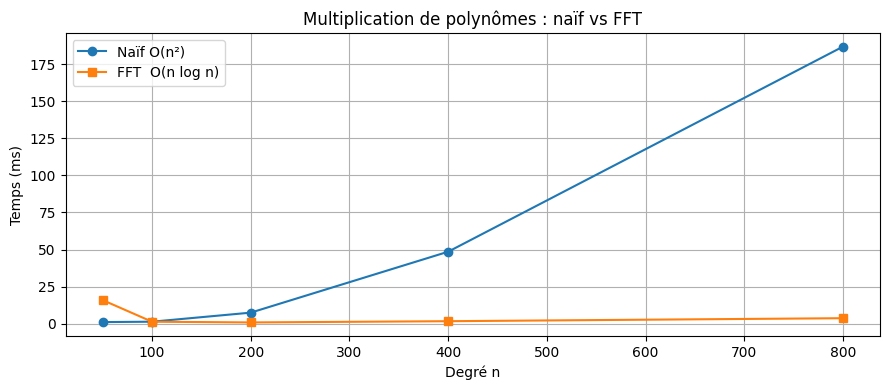

In [14]:
import numpy as np

def mul_fft(P, Q):
    """
    Multiplication de polynômes via FFT.
    Utilise numpy.fft : O(n log n) contre O(n^2) pour la méthode naïve.

    Principe :
      1. Évaluer P et Q en 2n racines de l'unité (FFT)
      2. Multiplier point par point
      3. Interpoler (IFFT)

    Référence : CLRS, chapitre 30.
    """
    n = P.degre + Q.degre + 1
    taille = 1
    while taille < n:
        taille *= 2
    fp = np.fft.fft(P.coeffs, taille)
    fq = np.fft.fft(Q.coeffs, taille)
    produit = np.fft.ifft(fp * fq).real
    coeffs_entiers = [round(c) for c in produit[:n]]
    return Polynome(coeffs_entiers)

degres_mul = [50, 100, 200, 400, 800]
temps_naif_mul = []
temps_fft_mul  = []

for d in degres_mul:
    coeffs = [random.randint(-5, 5) for _ in range(d + 1)]
    P = Polynome(coeffs)
    Q = Polynome(coeffs[:])
    tn = mesurer(P.__mul__, Q, rep=3)
    tf = mesurer(mul_fft, P, Q, rep=3)
    temps_naif_mul.append(tn)
    temps_fft_mul.append(tf)
    print(f"deg={d:3d} | Naïf: {tn*1e3:.3f} ms | FFT: {tf*1e3:.3f} ms")

plt.figure(figsize=(9, 4))
plt.plot(degres_mul, [t*1e3 for t in temps_naif_mul], 'o-', label='Naïf O(n²)')
plt.plot(degres_mul, [t*1e3 for t in temps_fft_mul],  's-', label='FFT  O(n log n)')
plt.xlabel('Degré n')
plt.ylabel('Temps (ms)')
plt.title('Multiplication de polynômes : naïf vs FFT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.3 Élimination de Gauss : complexité $\mathcal{O}(n^3)$

n= 10 : 0.300 ms
n= 20 : 1.713 ms
n= 40 : 36.701 ms
n= 80 : 81.047 ms
n=150 : 482.292 ms


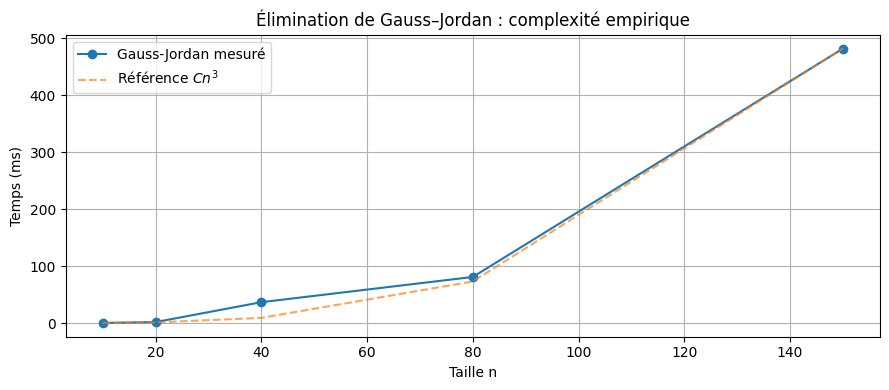

In [15]:
# NOTE : nécessite gauss_jordan implémenté

tailles = [10, 20, 40, 80, 150]
temps_gauss = []

for n in tailles:
    A = Matrice.aleatoire(n, n)
    # On ajoute n*I pour s'assurer d'une bonne conditionnabilité
    for i in range(n):
        A.data[i][i] += n
    b = [random.uniform(-10, 10) for _ in range(n)]
    t = mesurer(A.gauss_jordan, b, rep=3)
    temps_gauss.append(t)
    print(f"n={n:3d} : {t*1e3:.3f} ms")

# Ajustement : temps ≈ C * n^3
n3 = [n**3 for n in tailles]
C = temps_gauss[-1] / n3[-1]
ref_cubique = [C * v for v in n3]

plt.figure(figsize=(9, 4))
plt.plot(tailles, [t*1e3 for t in temps_gauss],    'o-', label='Gauss-Jordan mesuré')
plt.plot(tailles, [t*1e3 for t in ref_cubique],    '--', label='Référence $Cn^3$', alpha=0.7)
plt.xlabel('Taille n')
plt.ylabel('Temps (ms)')
plt.title('Élimination de Gauss–Jordan : complexité empirique')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Partie 6 — Exercices

Traitez **au moins 3 exercices** parmi ceux proposés. Les 2 premiers sont guidés (stubs fournis).

### Exercice 1 — Classe `Complexe` (guidé)

Implémentez la classe `Complexe` représentant $z = a + ib$ avec surcharge complète des opérateurs.  
Vérifiez que $|z \cdot w| = |z| \cdot |w|$.

In [16]:
class Complexe:
    def __init__(self, re, im=0):
        self.re = re
        self.im = im
        self.conjugue()
        self.module()

    def __add__(self, other):
        # TODO : (a+ib)+(c+id) = (a+c)+i(b+d)
        return Complexe(self.re + other.re,self.im + other.im )
        

    def __mul__(self, other):
        # TODO : (a+ib)(c+id) = (ac-bd) + i(ad+bc)
        return Complexe(((self.re*other.re)-(self.im*other.im)),((self.re*other.im)+(self.im*other.re)))
        

    def conjugue(self):
        # TODO : retourner (a-ib)
        return(self.re , - self.im)
    

    def module(self):
        # TODO : sqrt(re^2 + im^2)
        return math.sqrt(self.re**2 + self.im**2)
        

    def __str__(self):
        signe = '+' if self.im >= 0 else '-'
        return f"{self.re} {signe} {abs(self.im)}i"

    def __repr__(self):
        return f"Complexe({self.re}, {self.im})"

# Tests automatiques
z1, z2 = Complexe(3, 4), Complexe(1, -2)
assert abs(z1.module() - 5.0) < 1e-10, "Module de 3+4i"
assert abs((z1 * z2).module() - z1.module() * z2.module()) < 1e-10, "|zw| = |z||w|"
print(f"z1 = {z1},  z2 = {z2}")
print(f"z1 * z2 = {z1 * z2}")
print(f"z1_conjugue = {z1.conjugue()}")
print("Exercice 1 OK")

z1 = 3 + 4i,  z2 = 1 - 2i
z1 * z2 = 11 - 2i
z1_conjugue = (3, -4)
Exercice 1 OK


### Exercice 2 — Interpolation de Lagrange (guidé)

Étant donnés $n+1$ points $(x_0, y_0), \ldots, (x_n, y_n)$, le polynôme d'interpolation est :
$$L(X) = \sum_{i=0}^{n} y_i \prod_{j \neq i} \frac{X - x_j}{x_i - x_j}$$

Testez sur les points $(0,0), (1,1), (2,4)$ — résultat attendu : $X^2$.

In [17]:
def lagrange(xs, ys):
    """
    Calcule le polynôme d'interpolation de Lagrange.

    xs : liste de n+1 abscisses distinctes
    ys : liste de n+1 ordonnées
    Retourne : objet Polynome de degré <= n

    Complexité : O(n^2) en nombre de multiplications de polynômes.
    """
    n = len(xs)
    resultat = Polynome([0])
    for i in range(n):
        # Calculer le polynôme de base L_i
        # L_i = produit sur j != i de (X - x_j) / (x_i - x_j)
        Li = Polynome([1])
        for j in range(n):
            if j != i:
                
                #calcul du denominateur (scalaire)
                denom = xs[i] - xs[j]
                
                # TODO : multiplier Li par (X - xs[j]) / (xs[i] - xs[j])
                # Rappel : (X - c) = Polynome([-c, 1])
                Li = Li* Polynome([-xs[j] / denom, 1/ denom])
             
        resultat = resultat + ys[i] * Li
    return resultat

# Tests
P = lagrange([0, 1, 2], [0, 1, 4])
print(f"Interpolation : {P}")  # doit être X^2
assert abs(P.evaluer(1.5) - 1.5**2) < 1e-9
print("Exercice 2 OK")

Interpolation : X^2
Exercice 2 OK


### Exercice 3 — Vérification des axiomes d'anneau (ouvert)

In [18]:
def verifier_anneau(P, Q, R):
    """
    Vérifie les axiomes d'anneau pour des objets Polynome.

    À implémenter :
    - Commutativité de + : P + Q = Q + P
    - Associativité de * : (P*Q)*R = P*(Q*R)
    - Distributivité   : P*(Q+R) = P*Q + P*R
    - Élément neutre de + : P + zero = P
    - Élément neutre de * : P * un = P

    Retourne True si tous les axiomes sont vérifiés, False sinon.
    """
    # TODO
    #Commutativité de l'addition
    commutativite_addition = (P + Q == Q + P)
    
    # Associativité de la multiplicaton
    associativité_mul = ((P*Q)*R == P*(Q*R))
    
    # Distributivité de * par rapport à +
    distributivité_add = (P*(Q+R) == P*Q + P*R)
    
    # Élément neutre d'addition
    zero = Polynome([0])
    
    # Élément neutre de la multiplication
    un = Polynome([1])
    
    # Élément neutre de +
    neutre_addition = (P + zero == P)

    # Élément neutre de *
    neutre_multiplication = (P * un == P)
    
    # Vérification de tous les axiomes
    return (
        commutativite_addition
        and associativité_mul
        and distributivité_add
        and neutre_addition
        and neutre_multiplication)

P = Polynome([1, -1, 2])
Q = Polynome([3, 0, -1, 1])
R = Polynome([2, 1])
print(verifier_anneau(P, Q, R))

True


### Exercice 4 — Décomposition LU (ouvert)

Implémentez la décomposition $A = LU$ (sans pivot) comme méthode de la classe `Matrice`.  
Exprimez ensuite la résolution de $Ax = b$ en deux substitutions :  
$Ly = b$ (substitution avant) puis $Ux = y$ (substitution arrière).

In [19]:
def matrice_decomposition_LU(self):
    """
    Décomposition A = LU sans pivot.
    Retourne (L, U) où L est triangulaire inférieure (diagonale = 1)
    et U est triangulaire supérieure.
    Complexité : O(n^3).

    Référence : Trefethen & Bau, Numerical Linear Algebra, Lecture 20.
    """
    # TODO
    n = len(self.data)

    # Initialisation de L et U
    L = [[0.0 for j in range(n)] for i in range(n)]
    U = [[0.0 for j in range(n)] for i in range(n)]

    # Diagonale de L = 1
    for i in range(n):
        L[i][i] = 1.0

    # Algorithme de Doolittle
    for k in range(n):

        # Calcul de la ligne k de U
        for j in range(k, n):
            somme = 0.0

            for p in range(k):
                somme += L[k][p] * U[p][j]

            U[k][j] = self.data[k][j] - somme

        # Vérification du pivot
        if U[k][k] == 0:
            raise ValueError("Pivot nul : décomposition LU sans pivot impossible.")

        # Calcul de la colonne k de L
        for i in range(k + 1, n):
            somme = 0.0

            for p in range(k):
                somme += L[i][p] * U[p][k]

            L[i][k] = (self.data[i][k] - somme) / U[k][k]

    return Matrice(L), Matrice(U)
    

def substitution_avant(L, b):
    """Résout Ly = b, L triangulaire inférieure. O(n^2)."""
    # TODO
    n = len(b)
    y = [0.0 for _ in range(n)] # y = U*x vient de A = LU

    for i in range(n):
        somme = 0.0

        for j in range(i):
            somme += L.data[i][j] * y[j]

        if L.data[i][i] == 0:
            raise ValueError("Coefficient diagonal nul.")

        y[i] = (b[i] - somme) / L.data[i][i]

    return y

def substitution_arriere(U, b):
    """Résout Ux = b, U triangulaire supérieure. O(n^2)."""
    # TODO
    n = len(b)
    x = [0.0 for _ in range(n)]

    for i in range(n - 1, -1, -1):
        somme = 0.0

        for j in range(i + 1, n):
            somme += U.data[i][j] * x[j]

        if U.data[i][i] == 0:
            raise ValueError("Coefficient diagonal nul.")

        x[i] = (b[i] - somme) / U.data[i][i]

    return x

Matrice.decomposition_LU = matrice_decomposition_LU

#Tests
A = Matrice([[2, 1, 1], [4, 3, 3], [8, 7, 9]])
L, U = A.decomposition_LU()
print("L ="); print(L)
print("U ="); print(U)
print("LU ="); print(L * U)   # doit redonner A

L =
| 1  0  0 |
| 2  1  0 |
| 4  3  1 |
U =
| 2  1  1 |
| 0  1  1 |
| 0  0  2 |
LU =
| 2  1  1 |
| 4  3  3 |
| 8  7  9 |


### Décomposition LU — Algorithme de Doolittle (J'ai utilisé ci-déssus)
$$
A = LU
$$

où $L$ est une matrice triangulaire inférieure avec des $1$ sur la diagonale :

$$
L =
\begin{pmatrix}
1 & 0 & \cdots & 0 \\
l_{21} & 1 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
l_{n1} & l_{n2} & \cdots & 1
\end{pmatrix}
$$

et $U$ est une matrice triangulaire supérieure :

$$
U =
\begin{pmatrix}
u_{11} & u_{12} & \cdots & u_{1n} \\
0 & u_{22} & \cdots & u_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & u_{nn}
\end{pmatrix}.
$$

À l'étape $k$, on calcule d'abord les éléments de $U$ :

$$
\boxed{
U_{kj}
=
A_{kj}
-
\sum_{p=0}^{k-1} L_{kp}U_{pj}
}
\qquad j=k,\ldots,n-1
$$

Puis on calcule les éléments de $L$ :

$$
\boxed{
L_{ik}
=
\frac{
A_{ik}
-
\displaystyle\sum_{p=0}^{k-1}L_{ip}U_{pk}
}{
U_{kk}
}
}
\qquad i=k+1,\ldots,n-1
$$

et les éléments diagonaux de $L$ sont fixés à :

$$
\boxed{L_{kk}=1}.
$$

Ainsi, après toutes les étapes, on obtient :

$$
\boxed{A=LU}.
$$

### Exercice 5 — Méthode de Jacobi (ouvert)

L'itération de Jacobi met à jour :
$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j \neq i} a_{ij} x_j^{(k)}\right)$$

Convergente si $A$ est à diagonale strictement dominante.

In [20]:
def matrice_jacobi(self, b, tol=1e-8, max_iter=1000):
    """
    Résolution de Ax = b par itération de Jacobi.
    Retourne (x, nb_iterations).
    Complexité par itération : O(n^2).
    """
    # TODO
    
    n = len(self.data)

    # Approximation initiale
    x = [0.0 for _ in range(n)] # représente x**(0) = 0
    for iteration in range(1, max_iter + 1):

        # Nouvelle approximation
        x_new = [0.0 for _ in range(n)] # représente x**(k+1)

        # Calcul de chaque composante
        for i in range(n):

            somme = 0.0
            
            for j in range(n): #calcul de la somme de a[i][j]*x[j] parcourue de j!=i
                if j != i:
                    somme += self.data[i][j] * x[j]

            # Vérification du coefficient diagonal
            if self.data[i][i] == 0: # si la dénominateure est nulle
                raise ValueError("Coefficient diagonal nul.")

            x_new[i] = (b[i] - somme) / self.data[i][i]

        # Vérification de la convergence
        erreur = max(abs(x_new[i] - x[i])for i in range(n))

        # Mise à jour
        x = x_new

        if erreur < tol:
            return x, iteration

    return x, max_iter
    

Matrice.jacobi = matrice_jacobi

# Tester sur une matrice diagonalement dominante
n = 5
A = Matrice.identite(n) * 10
for i in range(n):
    for j in range(n):
        if i != j:
            A.data[i][j] = random.uniform(-1, 1)
b = [random.uniform(-5, 5) for _ in range(n)]
x_jacobi, iters = A.jacobi(b)
x_gauss = A.gauss_jordan(b)
print(f"Jacobi ({iters} it.) : {[round(v,6) for v in x_jacobi]}")
print(f"Gauss  (exact)    : {[round(v,6) for v in x_gauss]}")

Jacobi (8 it.) : [-0.101989, 0.33442, 0.307313, 0.445903, 0.245008]
Gauss  (exact)    : [-0.101989, 0.33442, 0.307313, 0.445903, 0.245008]


---
## Partie 7 — Problèmes Ouverts

Ces problèmes sont **optionnels** mais font partie des livrables bonus (+2 points chacun).

### Problème 1 — Corps de Galois $\mathbb{F}_2[X]/(P(X))$ (AES)

Le standard AES utilise le corps $\mathrm{GF}(2^8) = \mathbb{F}_2[X]/(X^8 + X^4 + X^3 + X + 1)$.  

**Objectif** : implémenter une classe `PolyMod` représentant les éléments de ce corps avec :
- Addition = XOR des coefficients modulo 2
- Multiplication modulo $P(X) = X^8 + X^4 + X^3 + X + 1$
- Inversion via l'algorithme d'Euclide étendu pour polynômes

> Référence : CLRS §31.7 ; FIPS 197 (standard AES, NIST).

In [21]:
# Problème 1 : Corps GF(2^8)
# Modulaire AES : P(X) = X^8 + X^4 + X^3 + X + 1
# Représentation : entier de 8 bits (bit i = coefficient de X^i)

# TODO : implémenter la classe PolyMod et les opérations

class PolyMod:
    # polynome irreductible d'AES
    # P(X) = X^8 + X^4 + X^3 + X + 1
    P = 0b100011011 # coefficients binaires

    def __init__(self, value):
        # on garde seulement les 8 bits de poids faible
        self.value = value & 0xFF

    def __repr__(self): # affichage de l'element en hexadécimale
        return f"PolyMod(0x{self.value:02X})"

    # Addition = XOR dans F2
    def __add__(self, other): # on a : 0+0 = 0; 0+1 = 1; 1+0 = 1; 1+1 = 0
        return PolyMod(self.value ^ other.value)

    # Multiplication modulo P(X)
    def __mul__(self, other):
        # on recupère les deux polynomes
        a, b = self.value, other.value
        
        # resultat initiale
        r = 0

        # Tant que b n'est pas nul
        while b:
            if b & 1: # si le bit courant de b vaut 1
                r ^= a # on ajoute a au résultat
 
            b >>= 1 # on passe au bit suivant de b
            a <<= 1 # multiplier pa X = décalage à gauche

            # Réduction modulo P(X)
            if a & 0x100:
                a ^= self.P

        return PolyMod(r)

    # Degré d'un polynôme
    @staticmethod
    def deg(p):
        return p.bit_length() - 1 if p else -1

    # Division euclidienne des polynômes
    @staticmethod
    def divmod_poly(a, b):
        q = 0

        while a and PolyMod.deg(a) >= PolyMod.deg(b):
            d = PolyMod.deg(a) - PolyMod.deg(b)
            q ^= 1 << d
            a ^= b << d

        return q, a

    # Multiplication de polynômes sans réduction
    @staticmethod
    def poly_mul(a, b):
        r = 0

        while b:
            if b & 1:
                r ^= a
            a <<= 1
            b >>= 1

        return r

    # Inverse par Euclide étendu
    def inverse(self):
        if self.value == 0:
            raise ZeroDivisionError("0 n'a pas d'inverse.")

        r0, r1 = self.P, self.value
        t0, t1 = 0, 1

        while r1:
            q, r = self.divmod_poly(r0, r1)
            r0, r1 = r1, r
            t0, t1 = t1, t0 ^ self.poly_mul(q, t1)

        _, inv = self.divmod_poly(t0, self.P)
        return PolyMod(inv)


a = PolyMod(0x57)
b = PolyMod(0x83)

print("a + b =", a + b)
print("a * b =", a * b)
print("inverse de a =", a.inverse())
print("a * inverse(a) =", a * a.inverse())

a + b = PolyMod(0xD4)
a * b = PolyMod(0xC1)
inverse de a = PolyMod(0xBF)
a * inverse(a) = PolyMod(0x01)


### Problème 2 — Classe `MatriceCreuse` (Sparse Matrix)

Une matrice creuse stocke uniquement les entrées non nulles.  
**Objectif** : classe `MatriceCreuse` héritant de `StructureAlgebrique`, avec stockage `dict {(i,j): val}`,
opérations `+`, `*`, produit matrice-vecteur, et comparaison d'utilisation mémoire.

> Référence : Strang, *CSE*, chapter 7.



## Matrice creuse (Sparse Matrix)
### je vais utiliser cette notion(Formule)

Une matrice creuse contient beaucoup de zéros.  
Pour économiser la mémoire, on stocke uniquement les coefficients non nuls dans un dictionnaire :

$$
A = \{(i,j) : a_{ij}\neq 0\}
$$

Par exemple :

$$
A=
\begin{pmatrix}
0&0&5\\
0&2&0\\
3&0&0
\end{pmatrix}
$$

est stockée comme :

```python
{(0,2): 5, (1,1): 2, (2,0): 3}

In [22]:
class MatriceCreuse(StructureAlgebrique):

    def __init__(self, n, m, data=None):
        self.n = n #nombre de ligne
        self.m = m #nombre de colonne
        self.data = data if data else {} #dictionnaire contenant uniquement les coefficients non nuls.

    def __getitem__(self, pos): # cela permet d'ecrire A[i, j]
        i, j = pos
        return self.data.get((i, j), 0)

    def __setitem__(self, pos, val):
        i, j = pos

        if val == 0:
            self.data.pop((i, j), None) #on ne stocke jamais les zéros.
        else:
            self.data[(i, j)] = val

    def __eq__(self, other):
        return (isinstance(other, MatriceCreuse)
            and self.n == other.n
            and self.m == other.m
            and self.data == other.data
        )

    @classmethod
    def zero(cls, n, m):
        return cls(n, m)

    #addition
    def __add__(self, other):
        C = MatriceCreuse(self.n, self.m, self.data.copy())

        for (i, j), val in other.data.items():
            C[i, j] = C[i, j] + val

        return C
    
    #multiplication
    def __mul__(self, other):
        C = MatriceCreuse(self.n, other.m)

        for (i, k), a in self.data.items():
            for (k2, j), b in other.data.items():
                if k == k2:
                    C[i, j] = C[i, j] + a * b

        return C

    def produit_vecteur(self, x):
        y = [0] * self.n

        for (i, j), val in self.data.items():
            y[i] += val * x[j]

        return y

    def __repr__(self):
        return str(self.data)
    
A = MatriceCreuse(3, 3)

A[0, 2] = 5
A[1, 1] = 2
A[2, 0] = 3

print("A =", A)

print("Ax =", A.produit_vecteur([1, 2, 3]))

B = A * A
print("A * A =", B)

A = {(0, 2): 5, (1, 1): 2, (2, 0): 3}
Ax = [15, 4, 3]
A * A = {(0, 0): 15, (1, 1): 4, (2, 2): 15}


### Problème 3 — Multiplication rapide par FFT

La multiplication naïve coûte $\mathcal{O}(n^2)$. Via FFT : $\mathcal{O}(n \log n)$.

**Objectif** : implémenter `mul_fft_entiers` pour des polynômes **à coefficients entiers**,
comparer avec la multiplication naïve pour des degrés allant jusqu'à $10^5$,  
puis expliquer pourquoi l'arithmétique flottante est problématique pour les grands entiers.

> Référence : CLRS, chapitre 30.

## Multiplication rapide par FFT (Réponses au question)

La multiplication de deux polynômes correspond à une convolution de leurs coefficients.

Pour
$$
A(X)=\sum_i a_iX^i,\qquad B(X)=\sum_j b_jX^j,
$$

on a
$$
c_k=\sum_{i+j=k}a_ib_j.
$$

- Multiplication naïve : $\mathcal{O}(n^2)$.
- Multiplication par FFT : $\mathcal{O}(n\log n)$.

La FFT transforme la convolution en produit :
$$
\operatorname{FFT}(A\ast B)
=
\operatorname{FFT}(A)\operatorname{FFT}(B).
$$

On effectue donc :
1. FFT de $A$ et $B$ ;
2. multiplication des transformées ;
3. FFT inverse.

### Problème des flottants

La FFT classique utilise des nombres flottants. 
Des erreurs d'arrondi apparaissent, par exemple :
$$
13 \longrightarrow 12.999999999999998.
$$

Pour de grands coefficients entiers, ces erreurs peuvent empêcher de retrouver exactement le résultat.

Pour des calculs entiers exacts, on peut utiliser une NTT.

$$
\boxed{\text{Naïf : }O(n^2)\qquad\text{FFT : }O(n\log n)}
$$

In [23]:
# Problème 3 : FFT pour entiers
# TODO

def mul_fft_entiers(A, B):
    n = len(A) + len(B) - 1

    # Taille suffisante pour la FFT
    N = 1
    while N < n:
        N *= 2

    # FFT des deux polynômes
    FA = np.fft.fft(A, N)
    FB = np.fft.fft(B, N)

    # Produit dans le domaine fréquentiel
    FC = FA * FB

    # FFT inverse
    C = np.fft.ifft(FC)

    # Les coefficients doivent être entiers
    C = np.rint(C.real).astype(object)

    return C[:n].tolist()

A = [1, 2, 3]
B = [4, 5]

print(mul_fft_entiers(A, B))

[4.0, 13.0, 22.0, 15.0]


In [24]:
# Multiplication naïve
def mul_naive(A, B):
    C = [0] * (len(A) + len(B) - 1)

    for i in range(len(A)):
        for j in range(len(B)):
            C[i + j] += A[i] * B[j]

    return C
# Comparaison
tailles = [100, 1000, 5000, 10000, 50000, 100000]

for n in tailles:

    A = [random.randint(0, 100) for _ in range(n)]
    B = [random.randint(0, 100) for _ in range(n)]

    # FFT
    debut = time.perf_counter()
    C_fft = mul_fft_entiers(A, B)
    temps_fft = time.perf_counter() - debut

    # Naïf seulement jusqu'à 10000
    if n <= 10000:
        debut = time.perf_counter()
        C_naive = mul_naive(A, B)
        temps_naive = time.perf_counter() - debut

        print(f"n = {n}")
        print(f"Naïf : {temps_naive:.6f} s")
        print(f"FFT  : {temps_fft:.6f} s")
        print(f"Même résultat : {C_naive == C_fft}")
        print()

    else:
        print(f"n = {n}")
        print(f"Naïf : non exécuté (trop coûteux)")
        print(f"FFT  : {temps_fft:.6f} s")
        print()

n = 100
Naïf : 0.003397 s
FFT  : 0.000391 s
Même résultat : True

n = 1000
Naïf : 0.315537 s
FFT  : 0.001334 s
Même résultat : True

n = 5000
Naïf : 7.195003 s
FFT  : 0.003609 s
Même résultat : True

n = 10000
Naïf : 27.214959 s
FFT  : 0.006678 s
Même résultat : True

n = 50000
Naïf : non exécuté (trop coûteux)
FFT  : 0.036233 s

n = 100000
Naïf : non exécuté (trop coûteux)
FFT  : 0.078011 s



---
## Partie 8 — Livrable

### Checklist

Avant de rendre votre notebook, vérifiez :

- [ ] Toutes les cellules s'exécutent sans erreur (sauf celles avec `raise NotImplementedError` non traité)
- [ ] Les stubs de la **Partie 2** (Polynome) sont tous implémentés
- [ ] Les stubs de la **Partie 3** (Matrice) sont tous implémentés
- [ ] Les graphiques de la **Partie 5** sont générés et commentés
- [ ] Au moins **3 exercices** de la Partie 6 sont traités
- [ ] Les tests Lean 4 de la Partie 4 sont dans un fichier `seance3.lean` dans le dépôt

### Rendu sur GitHub

```bash
git add seance3.ipynb seance3.lean
git commit -m "Séance 3 : POO avancée, Polynômes et Matrices"
git push
```

### Critères d'évaluation (10 points)

| Critère | Points |
|---------|--------|
| Correction et complétude de `Polynome` (add, mul, Horner, dérivée, pgcd) | 3 |
| Correction et complétude de `Matrice` (gauss_jordan, déterminant) | 3 |
| Exercices Lean 4 (au moins Exo 4.1 et 4.2) | 2 |
| Graphiques complexité commentés + Git propre | 2 |

**Bonus** : +2 pts par Problème ouvert complet et documenté.